# 03 — UC2 FedGen (KD-gen)

Train FedGen (Data-Free Knowledge Distillation with Generative Model)
across the alpha sweep. This is the main algorithm under study.

We test two variants:
- **FedGen (full)**: full model + generator exchange
- **FedGen (partial)**: only shared layers + generator (much lower comm cost)

Paper reference: Zhu et al. "Data-Free Knowledge Distillation for 
Heterogeneous Federated Learning" (ICML 2021)

Applied to regression: Salami, Wilhelmi et al. "Distributed Learning 
for Wi-Fi AP Load Prediction" (2024)

In [ ]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter


sys.path.insert(0, uc2.LIB_DIR)

print(f"Device: {uc2.DEFAULT_CONFIG['device']}")

Device: cuda:0


## Configuration

In [ ]:
ALPHAS = [0.5, 1.0, 5.0, 10.0]
MODEL = "lstm"

OVERRIDES = dict(
    num_glob_iters=100,
    local_epochs=50,
    num_users=20,
    early_stopping_patience=50,
    ensemble_lr=1e-4,
)

## Part A: FedGen (Full Model Exchange)

Standard FedGen: aggregates full model + trains/shares the generator.
Communication cost: C = (2|θ| + |ω|) × R × |S|

In [ ]:
results_fedgen_full = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  FedGen (full) — α={alpha}")
    print(f"{'='*60}")
    
    try:
        server, result = uc2.run_experiment(
            algorithm="FedGen",
            alpha=alpha,
            **OVERRIDES
        )
        results_fedgen_full[alpha] = result
        
        # Print final metrics
        glob_metrics = result["metrics"]["glob_test_metric"]
        if glob_metrics:
            best_idx = np.argmin([m.get("unscaled_mae", float("inf")) 
                                  for m in glob_metrics])
            best = glob_metrics[best_idx]
            print(f"\n  Best round: {best_idx}")
            print(f"  MAE (scaled):   {best.get('mae', 'N/A'):.4f}")
            print(f"  MAE (unscaled): {best.get('unscaled_mae', 'N/A'):.4f}")
            print(f"  MAPE:           {best.get('unscaled_mape', 'N/A'):.4f}")
        
        # Per-user breakdown
        per_user = uc2.evaluate_server(server)
        per_user_mae = per_user["metrics"].get("unscaled_mae", [])
        if per_user_mae:
            print(f"\n  Per-user MAE: mean={np.mean(per_user_mae):.4f}, "
                  f"std={np.std(per_user_mae):.4f}, "
                  f"CV={np.std(per_user_mae)/np.mean(per_user_mae):.3f}")
            
    except Exception as e:
        print(f"  [ERROR] {e}")
        import traceback
        traceback.print_exc()


  FedGen (full) — α=0.5
  [ERROR] No module named 'h5py'

  FedGen (full) — α=1.0
  [ERROR] No module named 'h5py'

  FedGen (full) — α=5.0
  [ERROR] No module named 'h5py'


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/746806030.py", line 9, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'
Traceback (most recent call last):
  File "/tmp/ipykernel_11559/746806030.py", lin


  FedGen (full) — α=10.0
  [ERROR] No module named 'h5py'


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/746806030.py", line 9, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'


## Part B: FedGen (Partial — Shared Layers Only)

Only the decoder (last FC layer) is aggregated at the server.
The encoder stays local → much lower communication cost.

Communication cost: C = (2|gr(θ)| + |ω|) × R × |S|
where |gr(θ)| ≈ 0.002 MB vs |θ| = 3.7 MB

**Note**: The `pFedGen` naming triggers `self.personalized = True` and
`self.mode = 'partial'` in the codebase. If this doesn't work with your
version, you can also manually set `specified_mode=True` or modify
the algorithm string.

In [ ]:
results_fedgen_partial = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  FedGen (partial) — α={alpha}")
    print(f"{'='*60}")
    
    # Result path uses a separate directory
    result_path = os.path.join(
        uc2.RESULTS, "fedgen_partial", f"alpha_{alpha}",
        MODEL, "rep_0"
    )
    
    try:
        # pFedGen triggers partial mode in the codebase
        server, result = uc2.run_experiment(
            algorithm="pFedGen",
            alpha=alpha,
            result_path=result_path,
            **OVERRIDES
        )
        # Relabel for clarity
        result["algorithm"] = "FedGen_partial"
        results_fedgen_partial[alpha] = result
        
        glob_metrics = result["metrics"]["glob_test_metric"]
        if glob_metrics:
            best_idx = np.argmin([m.get("unscaled_mae", float("inf")) 
                                  for m in glob_metrics])
            best = glob_metrics[best_idx]
            print(f"\n  Best round: {best_idx}")
            print(f"  MAE (scaled):   {best.get('mae', 'N/A'):.4f}")
            print(f"  MAE (unscaled): {best.get('unscaled_mae', 'N/A'):.4f}")
            
        per_user = uc2.evaluate_server(server)
        per_user_mae = per_user["metrics"].get("unscaled_mae", [])
        if per_user_mae:
            print(f"\n  Per-user MAE: mean={np.mean(per_user_mae):.4f}, "
                  f"std={np.std(per_user_mae):.4f}")
            
    except Exception as e:
        print(f"  [ERROR] {e}")
        import traceback
        traceback.print_exc()


  FedGen (partial) — α=0.5


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/2872999877.py", line 16, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'


  [ERROR] No module named 'h5py'

  FedGen (partial) — α=1.0
  [ERROR] No module named 'h5py'

  FedGen (partial) — α=5.0


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/2872999877.py", line 16, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'


  [ERROR] No module named 'h5py'

  FedGen (partial) — α=10.0


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/2872999877.py", line 16, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'


  [ERROR] No module named 'h5py'


Traceback (most recent call last):
  File "/tmp/ipykernel_11559/2872999877.py", line 16, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 357, in run_experiment
    server = create_server(args)
             ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 292, in create_server
    from FLAlgorithms.servers.serveravg import FedAvg
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serveravg.py", line 2, in <module>
    from FLAlgorithms.servers.serverbase import Server
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverbase.py", line 6, in <module>
    import h5py
ModuleNotFoundError: No module named 'h5py'


## Training Curves — Full vs Partial

/tmp/ipykernel_11559/145766302.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_11559/145766302.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


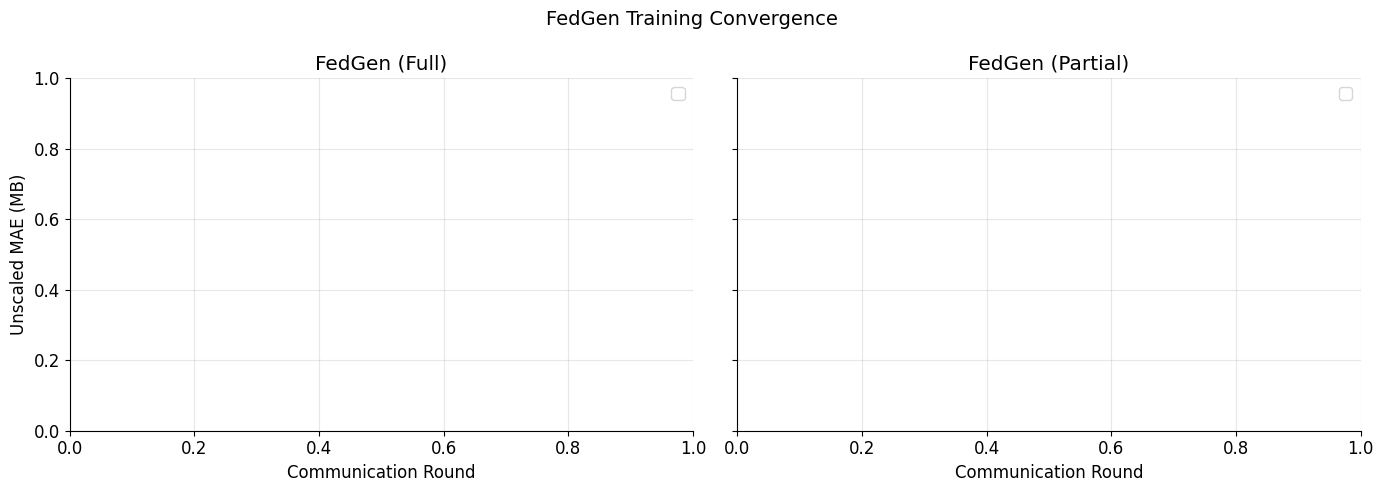

In [ ]:
import matplotlib.pyplot as plt
uc2.setup_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Full
ax = axes[0]
for alpha, r in sorted(results_fedgen_full.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)
ax.set_xlabel("Communication Round")
ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title("FedGen (Full)")
ax.legend()

# Partial
ax = axes[1]
for alpha, r in sorted(results_fedgen_partial.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)
ax.set_xlabel("Communication Round")
ax.set_title("FedGen (Partial)")
ax.legend()

plt.suptitle("FedGen Training Convergence", fontsize=14)
plt.tight_layout()
plt.show()

## Communication Cost Comparison

In [ ]:
print(f"{'α':>5} | {'FedGen Full (MB)':>18} | {'FedGen Partial (MB)':>20} | {'Reduction':>10}")
print("-" * 60)

for alpha in ALPHAS:
    n_full = results_fedgen_full.get(alpha, {}).get("n_rounds", 100)
    n_part = results_fedgen_partial.get(alpha, {}).get("n_rounds", 100)
    
    c_full = uc2.comm_cost_fedgen_full(n_full, 20)
    c_part = uc2.comm_cost_fedgen(n_part, 20)
    
    reduction = (1 - c_part / c_full) * 100 if c_full > 0 else 0
    print(f"{alpha:>5.1f} | {c_full:>18.1f} | {c_part:>20.1f} | {reduction:>9.1f}%")

    α |   FedGen Full (MB) |  FedGen Partial (MB) |  Reduction
------------------------------------------------------------
  0.5 |            15026.0 |                234.0 |      98.4%
  1.0 |            15026.0 |                234.0 |      98.4%
  5.0 |            15026.0 |                234.0 |      98.4%
 10.0 |            15026.0 |                234.0 |      98.4%


## Summary

- **FedGen (full)**: similar accuracy to FedAvg but with generator-based 
  regularization. Should degrade less at low α.
- **FedGen (partial)**: massive communication savings (~98% reduction) 
  at some accuracy cost. Key point for the Pareto analysis.
- Results saved to `results/fedgen/` and `results/fedgen_partial/`